In [1]:
#Import libraries
import pandas as pd
pd.set_option('display.max_columns', None)
from matplotlib import pyplot as plt

from datetime import timedelta

from statsmodels.stats.proportion import proportions_ztest


 # Setting tasks

 New analyst for an international online store. Your predecessor in this position launched an A/B test and quit. All that remains is the technical specification and test results. Technical task:

 - Test name: `recommender_system_test`;

 - Groups: A (control room), B (new payment funnel);

 - Launch date: 2020-12-07

 - Stop date for recruiting new users: 2020-12-21;

 - Stop date: 2021-01-04

 - Audience: 15% of new users from the EU region;

 - Purpose of the test: testing changes associated with the implementation of an improved recommendation system;

 - Expected effect: within 14 days from the moment of registration in the system, users will show better conversion in viewing product cards (`product_page` event), viewing the product basket (`product_card` event) and purchasing (`purchase`). At each step of the funnel `product_page → product_card → purchase` the improvement will be at least 10%;

 - Expected number of test participants: 6000.

 Download the test data, check the correctness of its execution and analyze the results.

 # Analysis of test results

 Let's set the test parameters:

In [2]:
test_start = pd.to_datetime('2020-12-07')
user_acquisition_duration = 16 - 1 # because the days are numbered from 0
activity_duration = 14 - 1
user_acquisition_end = test_start + timedelta(user_acquisition_duration)
test_end = test_start + timedelta(user_acquisition_duration + activity_duration)

required_participants = 6000

test_name = 'recommender_system_test'


 ## 1 Loading and preparing data

 Loading data, converting dates and times:

In [3]:
# Load data
test_participants = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_participants.csv')
new_users = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_new_users.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_events.csv')
marketing_events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_project_marketing_events.csv')

#new_users = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_new_users.csv').merge(test_participants, on = 'user_id', how = 'left')
#events = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_events.csv').merge(test_participants, on = 'user_id', how = 'left')


In [4]:
test_participants.info()
test_participants.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  18268 non-null  object
 1   group    18268 non-null  object
 2   ab_test  18268 non-null  object
dtypes: object(3)
memory usage: 428.3+ KB


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test


In [5]:
new_users.info()
new_users.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61733 entries, 0 to 61732
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     61733 non-null  object
 1   first_date  61733 non-null  object
 2   region      61733 non-null  object
 3   device      61733 non-null  object
dtypes: object(4)
memory usage: 1.9+ MB


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC


In [6]:
events.info()
events.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     440317 non-null  object 
 1   event_dt    440317 non-null  object 
 2   event_name  440317 non-null  object 
 3   details     62740 non-null   float64
dtypes: float64(1), object(3)
memory usage: 13.4+ MB


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99


In [7]:
marketing_events.info()
marketing_events.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19


In [8]:
#change data types
new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])

In [9]:
# merge DFs
new_users = new_users.merge(test_participants, on = 'user_id', how = 'left')
new_users.head(3)


,user_id,first_date,region,device,group,ab_test
0,D72A72121175D8BE,2020-12-07,EU,PC,A,recommender_system_test
1,F1C668619DFE6E65,2020-12-07,N.America,Android,NaN,NaN
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC,A,interface_eu_test


In [10]:
events = events.merge(test_participants, on = 'user_id', how = 'left')
events.head(3)

,user_id,event_dt,event_name,details,group,ab_test
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99,NaN,NaN
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99,NaN,NaN
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99,NaN,NaN


 Since we ourselves did not plan the test and did not monitor its implementation, we first need to check the adequacy of its implementation. Let's check:

 - Did the test coincide in time with any marketing events?

 - Did the test audience overlap with competing tests;

 - Was the test audience formed correctly;

 - Was there an even distribution among test groups?

 ## 2 Checking the correctness of the test



 Let's check the coincidence with marketing activities:

In [11]:
# %%
marketing_events['is_eu'] = marketing_events['regions'].apply(lambda x: 'EU' in x.split(', '))
eu_marketing_events = marketing_events.query('is_eu == True')
print('Test time limits: ', test_start, test_end)
eu_marketing_events.query('(start_dt >= @test_start and start_dt <= @test_end) or \
                           (finish_dt >= @test_start and finish_dt <= @test_end)')


Test time limits:  2020-12-07 00:00:00 2021-01-04 00:00:00


,name,regions,start_dt,finish_dt,is_eu
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03,True


 The test strongly overlaps with the New Year's promotion in the EU. This is not very good - you need to avoid such situations.

 Let's see how things are going with competing tests:

 Let's see how we are doing with the test participants:

In [12]:
# %%
test_participants.groupby(['ab_test', 'group']).agg({'user_id': 'nunique'})


user_id
ab_test                 group         
interface_eu_test       A         5831
                        B         5736
recommender_system_test A         3824
                        B         2877

 In addition to our test, it turns out there was also a parallel test interface_eu_test. Judging by the name, it was carried out in the EU region and could affect the result of our test. Let's see if there was an audience overlap and, if so, how big:

In [13]:
# %%
new_test_users = test_participants.query('ab_test == @test_name')['user_id'].unique()
both_test_participants = (test_participants[test_participants['user_id'].isin(new_test_users)]
                          .groupby('user_id').agg({'ab_test': 'nunique', 'group': 'nunique'})
                          .query('ab_test > 1 or group > 1').shape[0])
print('Intersection of test audiences: {} ({:.2%})'.format(both_test_participants, 
                                                         both_test_participants / len(new_test_users)))



Intersection of test audiences: 1602 (23.91%)


 Quite a lot, competing tests were clearly launched incorrectly.

 Let's remove from the data everything related to the competing test:

In [14]:
test_participants = test_participants.query('ab_test == @test_name')
new_users = new_users.query('ab_test != "interface_eu_test"')
events = events.query('ab_test != "interface_eu_test"')


 Let's check the correctness of the test audience.

 Let's see if the test included mainly users from the EU:

In [15]:
report = new_users.query('ab_test == @test_name').groupby('region').agg({'user_id': 'nunique'}).rename(columns = {'user_id': 'Participants'})
report['% Participants'] = (report['Participants'] / report['Participants'].sum()).round(2)
report.sort_values(by = 'Participants', ascending = False)


,Participants,% Participants
region,,
EU,6351,0.95
N.America,223,0.03
APAC,72,0.01
CIS,55,0.01


 There is a slight deviation - 5% of the test are users from other regions. This is acceptable.

 Now let’s check whether the test included the required proportion of users from the EU:

In [16]:
eu_test_users = new_users.query('region == "EU" and ab_test == @test_name').shape[0]
eu_users = new_users.query('region == "EU" and first_date >= @test_start and first_date <= @user_acquisition_end').shape[0]
eu_test_users / eu_users


0.181033008380366

 It turns out that instead of 15%, 18% of users from the EU are included in the test. Let's check how statistically significant this difference is.

 To do this, we will need to set and adjust the significance level. In this project we are going to run 5 statistical tests:

 - Checking % of EU audience in the test;

 - Checking the correct distribution of participants into test groups;

 - Three tests for each step of the monetization funnel.

 We carry out the Bonferroni correction and perform a z-test:

In [17]:
alpha = 0.05
alpha = alpha / 5
pvalue = proportions_ztest(eu_test_users, eu_users, value = 0.15)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('The null hypothesis is not rejected: for a user from the EU region, the probability of being tested is 15%.')
else:
    print('The null hypothesis is rejected: for a user from the EU region, the probability of being tested is different from 15%.')


p-value: 1.7277902563754723e-51
The null hypothesis is rejected: for a user from the EU region, the probability of being tested is different from 15%.


 3% more users were sent to the test than planned. Unpleasant, but not very scary. It is unlikely that 3% could significantly affect the monetization of the entire EU audience.

 Let's check whether users are evenly distributed in groups:

In [18]:
a_users = new_users.query('group == "A" and ab_test == @test_name').shape[0]
all_participants = new_users.query('ab_test == @test_name').shape[0]
a_users / all_participants


0.5706610953589016

The test participants were supposed to be divided in half, but it looks like 57% of the participants ended up in Group A instead of 50.

Let's see how statistically significant this result is:

In [19]:
pvalue = proportions_ztest(a_users, all_participants, value = 0.5)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('The null hypothesis is not rejected: the probability of being in group A is 50%')
else:
    print('The null hypothesis is rejected: the probability of being in group A is different from 50%')


p-value: 1.50536508194716e-31
The null hypothesis is rejected: the probability of being in group A is different from 50%


The test was not conducted correctly, as it did not follow the requirements and was affected by overlap with a parallel test.  

Despite these issues, the results will still be reviewed to identify any insights that may be useful for improving the design and execution of future tests, starting with an analysis of the cumulative metrics.

 ## 3 Analysis of cumulative metrics

Let's leave only the records related to the test in the data:

In [20]:
test_participants = test_participants.query('ab_test == @test_name')
new_users = new_users.query('ab_test == @test_name')
events = events.query('ab_test == @test_name')


Since the test has already been run, let's set the current acquisition duration equal to the full acquisition duration:

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18244\205646047.py:69: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cumulative_test_payers.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 3), grid = True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_18244\205646047.py:76: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cumulative_test_carters.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 4), grid = True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_18244\205646047.py:83: FutureWarning: Downcasting

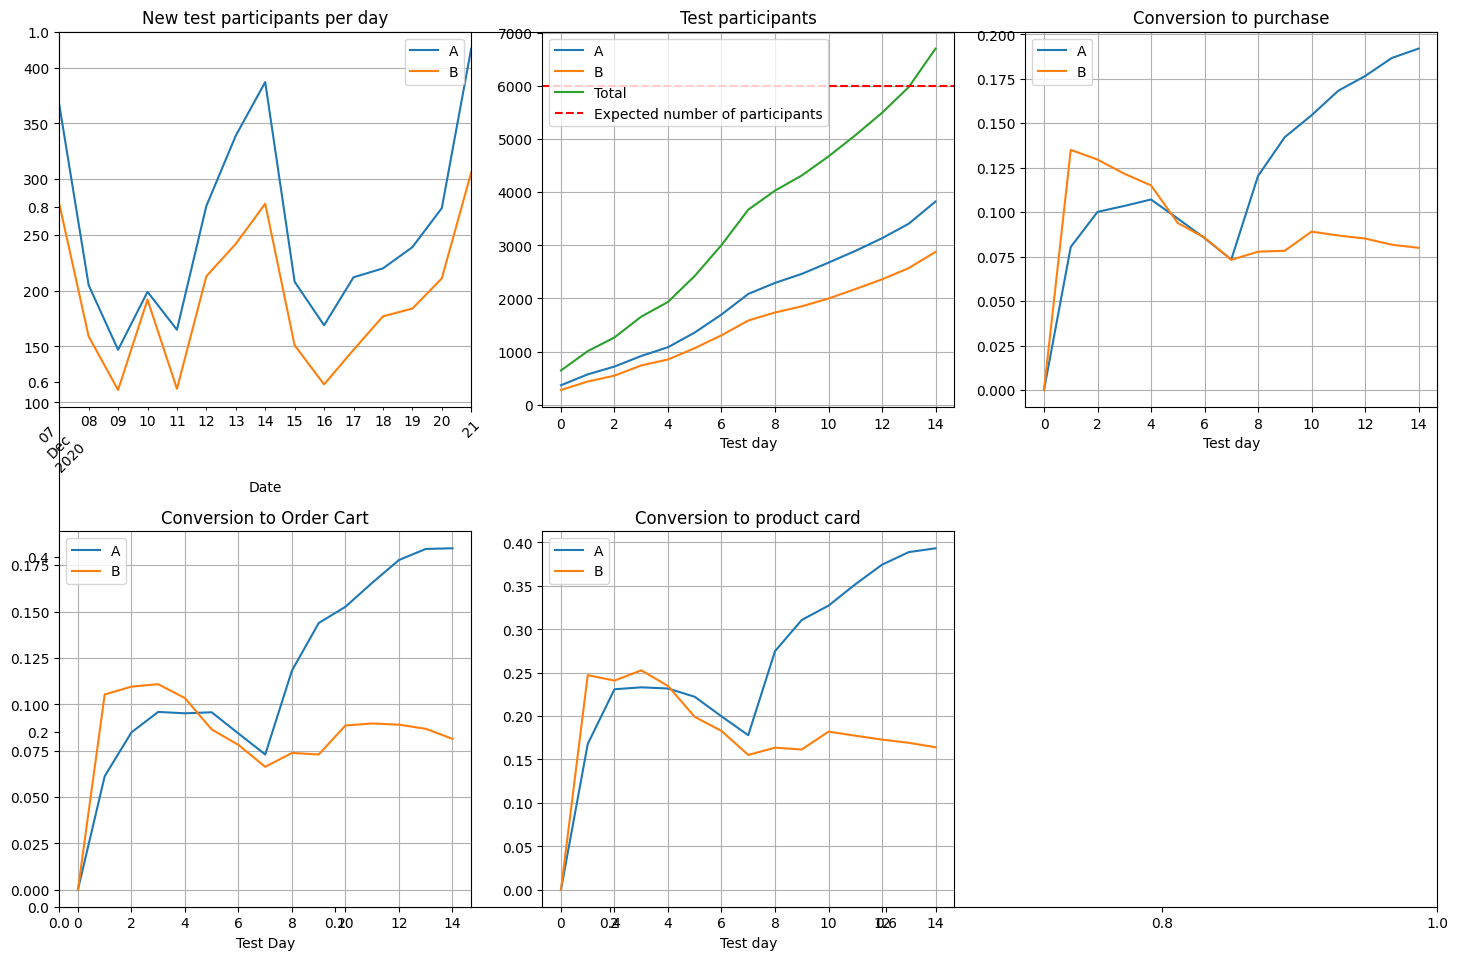

In [21]:
current_aquisition_duration = user_acquisition_duration
test_dates = pd.date_range(start = test_start, periods = current_aquisition_duration)

plt.subplots(figsize = (15, 10))

cumulative_test_users = pd.DataFrame(columns = ['A', 'B'])
cumulative_test_carters = pd.DataFrame(columns = ['A', 'B'])
cumulative_test_product = pd.DataFrame(columns = ['A', 'B'])
cumulative_test_payers = pd.DataFrame(columns = ['A', 'B'])


for i, dt in enumerate(test_dates):

    #test participants
    current_test_users = new_users.query('first_date <= @dt').groupby('group').agg({'user_id': 'nunique'}).T
    current_test_users['date'] = dt
    current_test_users['test_day'] = i
    cumulative_test_users = pd.concat([cumulative_test_users, current_test_users], sort = False)
    
    ##product card
    current_test_prod = events.query('event_name == "product_page"').query('event_dt <= @dt').groupby('user_id').agg({'details': 'count'})
    current_test_product = (new_users.merge(current_test_prod, on = 'user_id', how = 'inner')
                                     .query('first_date <= @dt')
                                     .groupby('group').agg({'user_id': 'nunique'}).T)
    current_test_product['date'] = dt
    current_test_product['test_day'] = i
    cumulative_test_product = pd.concat([cumulative_test_product, current_test_product], sort = False)
    
    ## Order Cart  
    current_test_cart = events.query('event_name == "product_cart"').query('event_dt <= @dt').groupby('user_id').agg({'details': 'count'})
    current_test_carters = (new_users.merge(current_test_cart, on = 'user_id', how = 'inner')
                                     .query('first_date <= @dt')
                                     .groupby('group').agg({'user_id': 'nunique'}).T)
    current_test_carters['date'] = dt
    current_test_carters['test_day'] = i
    cumulative_test_carters = pd.concat([cumulative_test_carters, current_test_carters], sort = False)

    ## Paying test participants
    current_test_purchases = events.query('event_name == "purchase"').query('event_dt <= @dt').groupby('user_id').agg({'details': 'sum'})
    current_test_payers = (new_users.merge(current_test_purchases, on = 'user_id', how = 'inner')
                                    .query('first_date <= @dt')
                                    .groupby('group').agg({'user_id': 'nunique'}).T)
    current_test_payers['date'] = dt
    current_test_payers['test_day'] = i
    cumulative_test_payers = pd.concat([cumulative_test_payers, current_test_payers], sort = False)

# New test participants without accumulation  / without prior history
pd.pivot_table(new_users, 
               index = 'first_date', 
               columns = 'group', 
               values = 'user_id', 
               aggfunc = 'count').plot(ax = plt.subplot(2, 3, 1), grid = True)
plt.title('New test participants per day')
plt.xlabel('Date')
plt.xticks(rotation = 45)
plt.legend()

#test participants
cumulative_test_users = cumulative_test_users.query('date >= @test_start and date <= @user_acquisition_end').set_index('test_day')[['A', 'B']]
cumulative_test_users['Total'] = cumulative_test_users['A'] + cumulative_test_users['B']
cumulative_test_users.plot(ax = plt.subplot(2, 3, 2), grid = True)
plt.axhline(y = required_participants, label = 'Expected number of participants', color = 'red', linestyle = '--')
plt.title('Test participants')
plt.legend()
plt.xlabel('Test day')

#conversions 
cumulative_test_payers = cumulative_test_payers.query('date >= @test_start and date <= @user_acquisition_end').set_index('test_day')[['A', 'B']]
cumulative_test_payers.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 3), grid = True)
plt.title('Conversion to purchase')
plt.legend()
plt.xlabel('Test day')

# conversions to cart
cumulative_test_carters = cumulative_test_carters.query('date >= @test_start and date <= @user_acquisition_end').set_index('test_day')[['A', 'B']]
cumulative_test_carters.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 4), grid = True)
plt.title('Conversion to Order Cart')
plt.legend()
plt.xlabel('Test Day')

# conversions to cart
cumulative_test_product = cumulative_test_product.query('date >= @test_start and date <= @user_acquisition_end').set_index('test_day')[['A', 'B']]
cumulative_test_product.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 5), grid = True)
plt.title('Conversion to product card')
plt.legend()
plt.xlabel('Test day')

plt.tight_layout()
plt.show()


 Conclusions and Observations:
- The data shows weekly seasonality, and the required participant level was reached. In this regard, the test was well planned.
- Conversions at each step of the funnel diverged noticeably, with Group A seemingly leading.

We will verify this using statistical tests.

 ## 4 Hypothesis Testing

We will check whether there is a difference between the groups in purchase conversion. 

A z-test will be used, since we are testing a proportion:

In [22]:
report = test_participants.merge(events.query('event_name == "purchase"').groupby('user_id').agg({'details': 'count'}), on = 'user_id', how = 'left')
report['is_buyer'] = (report['details'] > 0).astype(int)
report = (report.groupby('group').agg({'user_id': 'count', 'is_buyer': 'sum'})
                                 .rename(columns = {'user_id': 'Participants', 'is_buyer': 'Buyers'}))
report['Conversion'] = (report['Buyers'] / report['Participants']).round(2)
report


,Participants,Buyers,Conversion
group,,,
A,3824,872,0.23
B,2877,256,0.09


In [23]:
count = list(report['Buyers'].values)
nobs = list(report['Participants'].values)

pvalue = proportions_ztest(count, nobs)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('The null hypothesis is not rejected: there is no difference in purchase conversion rate between groups A and B.')
else:
    print('The null hypothesis is rejected: there is a difference in the % conversion to purchase between groups A and B.')


p-value: 3.044251010416302e-51
The null hypothesis is rejected: there is a difference in the % conversion to purchase between groups A and B.


Let's check if there is a difference between the groups in % of users who visited the product page. 

We use a z-test, since we are testing a proportion:

In [24]:
report = test_participants.merge(events.query('event_name == "product_page"').groupby('user_id').agg({'event_dt': 'count'}), on = 'user_id', how = 'left')
report['is_buyer'] = (report['event_dt'] > 0).astype(int)
report = (report.groupby('group').agg({'user_id': 'count', 'is_buyer': 'sum'})
                                 .rename(columns = {'user_id': 'Participants', 'is_buyer': 'Users on the product page'}))
report['Conversion'] = (report['Users on the product page'] / report['Participants']).round(2)
report


,Participants,Users on the product page,Conversion
group,,,
A,3824,1780,0.47
B,2877,523,0.18


In [25]:
count = list(report['Users on the product page'].values)
nobs = list(report['Participants'].values)

pvalue = proportions_ztest(count, nobs)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('НThe null hypothesis is not rejected: there is no difference between groups A and B in the % of users who saw the product page.')
else:
    print('The null hypothesis is rejected: There is a difference in the % of users who saw the product page between groups A and B.')


p-value: 2.0521014454928e-129
The null hypothesis is rejected: There is a difference in the % of users who saw the product page between groups A and B.


Let's check if there is a difference between the groups in % of users who visited the cart page.

We use a z-test, since we are testing a proportion:

In [26]:
report = test_participants.merge(events.query('event_name == "product_cart"').groupby('user_id').agg({'event_dt': 'count'}), on = 'user_id', how = 'left')
report['is_buyer'] = (report['event_dt'] > 0).astype(int)
report = (report.groupby('group').agg({'user_id': 'count', 'is_buyer': 'sum'})
                                 .rename(columns = {'user_id': 'Participants', 'is_buyer': 'Users on the cart page'}))
report['Conversion'] = (report['Users on the cart page'] / report['Participants']).round(2)
report


,Participants,Users on the cart page,Conversion
group,,,
A,3824,824,0.22
B,2877,255,0.09


In [27]:
count = list(report['Users on the cart page'].values)
nobs = list(report['Participants'].values)

pvalue = proportions_ztest(count, nobs)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('The null hypothesis is not rejected: There is no difference between groups A and B in the % of users who saw the cart page.')
else:
    print('The null hypothesis is rejected: There is a difference between groups A and B in the % of users who saw the shopping cart page.')


p-value: 1.95915226847382e-44
The null hypothesis is rejected: There is a difference between groups A and B in the % of users who saw the shopping cart page.


The difference in favor of control group A, which we saw when analyzing the cumulative metrics, is confirmed by statistical tests. 

It seems that the improved recommendation system has not improved anything, but quite the opposite. Of course, our test was not carried out correctly, but these improvements should be treated with suspicion. 

We recommend conducting another test - this time according to the technical specifications.

## Conclusions

The test was conducted incorrectly:
- The test coincided with New Year promotions in the EU region.
- Participants were simultaneously involved in another test.
- The test included 3% more participants from the EU region than required.
- Participants were unevenly distributed between test groups, with Group A receiving 57% of the participants.

* Therefore, the test results cannot be considered valid, and no business decisions should be based on them.

Nevertheless, the results indicate caution regarding the new recommendation system:
- Conversion in the test group was significantly lower than in the control group, suggesting potential issues.

Recommendation:
- Conduct another test to obtain valid and reliable results.